In [1]:
# Step 0 - set up environment

import json

from asarix.main import process_params
from asarix.default_parameters import PARAMETERS
from asarix.signature_generator import SignatureGenerator

In [ ]:
# Step 1 - generate signatures for metformin

metformin_cpd = "/Users/mitchjo/Projects/Asari-X/Asari-X/notebooks/metformin_search_bartlett/metformin.json"
null_rxn = "/Users/mitchjo/Projects/Asari-X/Asari-X/notebooks/metformin_search_bartlett/stub_rxn.json"

params = PARAMETERS
configure = {
    'compounds': json.load(open(metformin_cpd))["data"],
    'reactions': json.load(open(null_rxn))["data"],
    'reaction_depth': 1,
}
params.update(configure)

SG = SignatureGenerator.from_compounds_reactions(params['compounds'], params['reactions'])
SG.generate_signatures(reaction_depth=3)
SG.save_signatures("./metformin_signatures.json")

Iterating Depth:   0%|          | 0/4 [00:00<?, ?it/s]

()


({'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}},)


({'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}}, {'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}})


({'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}}, {'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}}, {'elemental_difference': 'O', 'reaction_name': 'None', 'mass_delta': 0, 'frequency': 87, 'manually_curated': 'yes', 'formula_dict': {}})


{'reaction_name': '', 'formula_dict': {}}
{'reaction_name': 'None', 'formula_dict': defaultdict(<class 'int'>, {})}
{'reaction_name': 'None+None', 'formula_dict': defaultdict(<class 'int'>, {})}
{'reaction_name': 'None+None+None', 'formula_dict': defaultdict(<class 'int'>, {})}


In [3]:
# this is to show format, demo only 
print("\nCompound Format:\n")
with open(metformin_cpd) as cpd_fh:
    print(json.dumps(json.load(cpd_fh), indent=4))

print("\nReactions Format:\n")
with open(null_rxn) as rxn_fh:
    print(json.dumps(json.load(rxn_fh), indent=4))

print("\nSignatures Format:\n")
with open("./metformin_signatures.json") as sig_fh:
    print(json.dumps(json.load(sig_fh), indent=4))



Compound Format:

{
    "data": [
        {
            "primary_id": "B1970",
            "primary_db": "FDA_drug_library",
            "name": "Metformin",
            "neutral_formula": "C4H11N5",
            "neutral_formula_mass": 165.07812309054998,
            "charged_formula": null,
            "charge": 0,
            "charged_formula_mass": null
        }
    ]
}

Reactions Format:

{
    "data": [
        {
            "elemental_difference": "O",
            "reaction_name": "None",
            "mass_delta": 0,
            "frequency": 87,
            "manually_curated": "yes",
            "formula_dict": {}
        }
    ]
}

Signatures Format:

{
    "data": [
        {
            "neutral_formula_mass": 129.101445,
            "neutral_formula": "C4H11N5",
            "reactions": "",
            "uuid": "a4c34438-4121-4015-9f2a-66f018f03343"
        },
        {
            "neutral_formula_mass": 129.101445,
            "neutral_formula": "C4H11N5",
            "rea

In [4]:
# Step 2 - signature search

configure = {
    'input': "/Users/mitchjo/Projects/Asari-X/Asari-X/TestData",
    'signatures': json.load(open("./metformin_signatures.json"))['data'],
    'mz_tolerance_ppm': 5,
}
params.update(configure)

from asarix.scan_search import mzML_Searcher
XS = mzML_Searcher(params['signatures'],
              params['input'],
              params['mz_tolerance_ppm'])

XS.search()


100%|██████████| 1/1 [00:00<00:00, 755.87it/s]


searching mzML:   0%|          | 1/358 [00:00<04:20,  1.37it/s]

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_074.mzML


searching mzML:   1%|          | 2/358 [00:01<04:02,  1.47it/s]

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_131.mzML


...

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_237.mzML


searching mzML: 100%|█████████▉| 357/358 [03:58<00:00,  1.55it/s]

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_149.mzML


searching mzML: 100%|██████████| 358/358 [03:59<00:00,  1.49it/s]

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_260.mzML


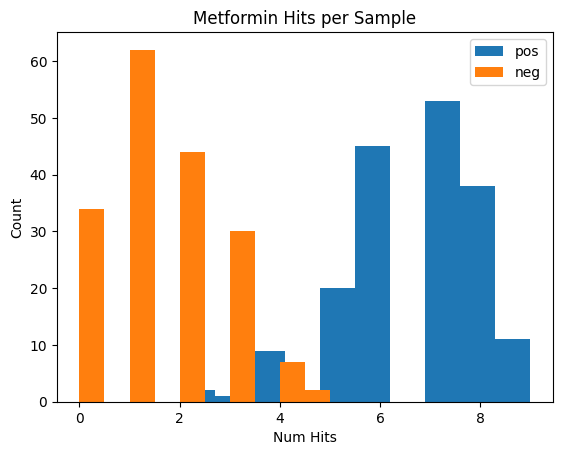

In [5]:
# example results

import os 
scan_data = []
for dir, _, files in os.walk("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    for f in files:
        if f.endswith("_ASARIX.json"):
            scan_data.append(os.path.join(os.path.abspath(dir), f))

num_hits = {}
for f in scan_data:
    with open(f) as fh:
        data = json.load(fh)
        if data['mode'] not in num_hits:
            num_hits[data['mode']] = []
        num_hits[data['mode']].append(len(data['hits']))

import matplotlib.pyplot as plt
for mode in num_hits.keys():
    plt.hist(num_hits[mode], label=mode)
plt.xlabel("Num Hits")
plt.ylabel("Count")
plt.title("Metformin Hits per Sample")
plt.legend()
plt.show()

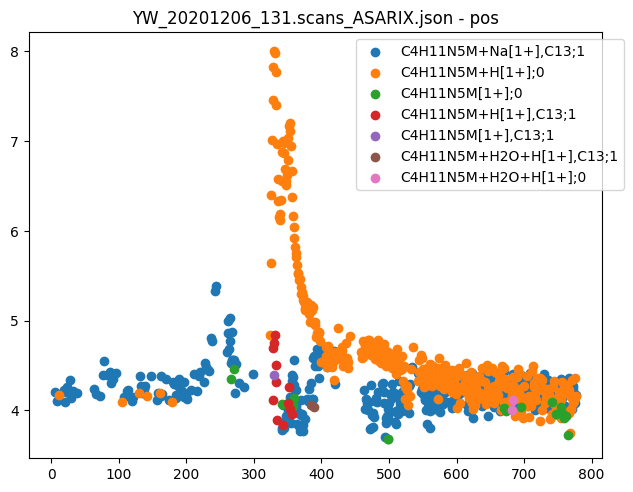

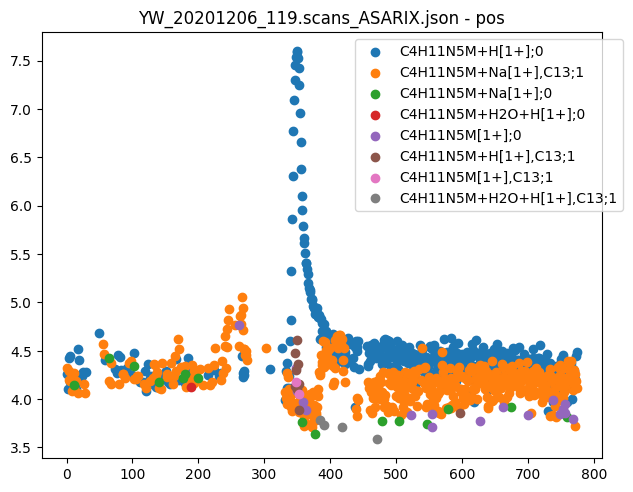

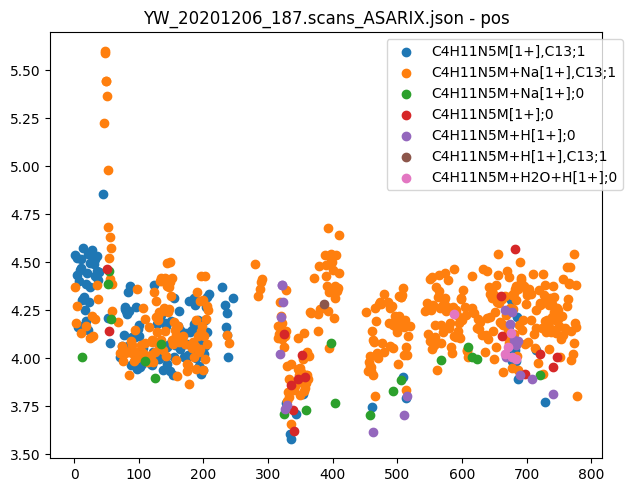

In [6]:
import numpy as np

example = scan_data[6]
data = json.load(open(example))
for name, hit_list in data['hits'].items():
    Xs, Ys = [], []
    for scan, intensity, mz, rtime in hit_list:
        Xs.append(scan)
        Ys.append(intensity)
    plt.scatter(Xs, np.log10(np.array(Ys)+1), label=name.split("_")[0] + name.split("$")[-1])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.title(os.path.basename(example) + " - " + data['mode'])
plt.show()

import numpy as np

example = scan_data[3]
data = json.load(open(example))
for name, hit_list in data['hits'].items():
    Xs, Ys = [], []
    for scan, intensity, mz, rtime in hit_list:
        Xs.append(scan)
        Ys.append(intensity)
    plt.scatter(Xs, np.log10(np.array(Ys)+1), label=name.split("_")[0] + name.split("$")[-1])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.title(os.path.basename(example) + " - " + data['mode'])
plt.show()

example = scan_data[0]
data = json.load(open(example))
for name, hit_list in data['hits'].items():
    Xs, Ys = [], []
    for scan, intensity, mz, rtime in hit_list:
        Xs.append(scan)
        Ys.append(intensity)
    plt.scatter(Xs, np.log10(np.array(Ys)+1), label=name.split("_")[0] + name.split("$")[-1])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.title(os.path.basename(example) + " - " + data['mode'])
plt.show()
        

In [ ]:
# Step 3 - Scoring Scans

from asarix.scan_score import mzML_Search_Scorer

configure = {
    'input': "/Users/mitchjo/Projects/Asari-X/Asari-X/TestData",
    'snr_cutoff': 3,
    'scan_cutoff': 5
}

params.update(configure)

scan_files = mzML_Search_Scorer.filter_inputs(params['input'], extension_filter=".scans_ASARIX.json")
SS = mzML_Search_Scorer(params['snr_cutoff'], params['scan_cutoff'], scan_files)
SS.score()

/Users/mitchjo/Projects/Asari-X/Asari-X/TestData/YW_20201206_131.scans_ASARIX.json


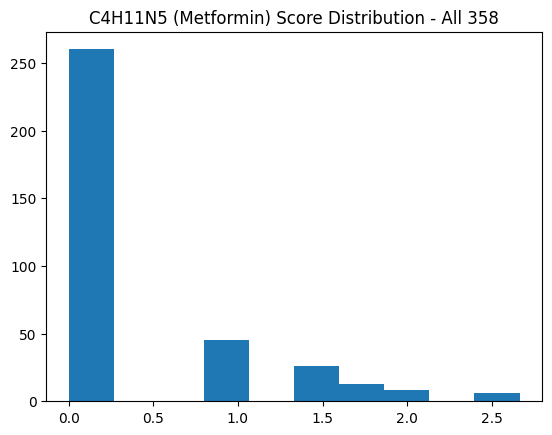

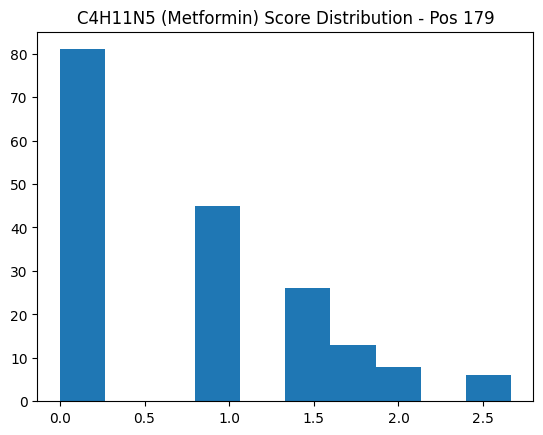

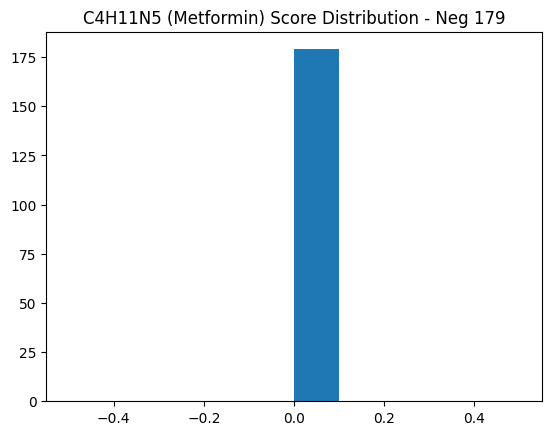

{'YW_20201206_071.mzML': 'Metformin', 'YW_20201206_072.mzML': 'Metformin', 'YW_20201206_089.mzML': 'Metformin', 'YW_20201206_090.mzML': 'Metformin', 'YW_20201206_101.mzML': 'Metformin', 'YW_20201206_102.mzML': 'Metformin', 'YW_20201206_115.mzML': 'Metformin', 'YW_20201206_116.mzML': 'Metformin', 'YW_20201206_135.mzML': 'Metformin', 'YW_20201206_136.mzML': 'Metformin', 'YW_20201206_163.mzML': 'Metformin', 'YW_20201206_164.mzML': 'Metformin', 'YW_20201206_199.mzML': 'Metformin', 'YW_20201206_200.mzML': 'Metformin', 'YW_20201206_227.mzML': 'Metformin', 'YW_20201206_228.mzML': 'Metformin', 'YW_20201210_071.mzML': 'Metformin', 'YW_20201210_072.mzML': 'Metformin', 'YW_20201210_089.mzML': 'Metformin', 'YW_20201210_090.mzML': 'Metformin', 'YW_20201210_101.mzML': 'Metformin', 'YW_20201210_102.mzML': 'Metformin', 'YW_20201210_115.mzML': 'Metformin', 'YW_20201210_116.mzML': 'Metformin', 'YW_20201210_135.mzML': 'Metformin', 'YW_20201210_136.mzML': 'Metformin', 'YW_20201210_163.mzML': 'Metformin', 

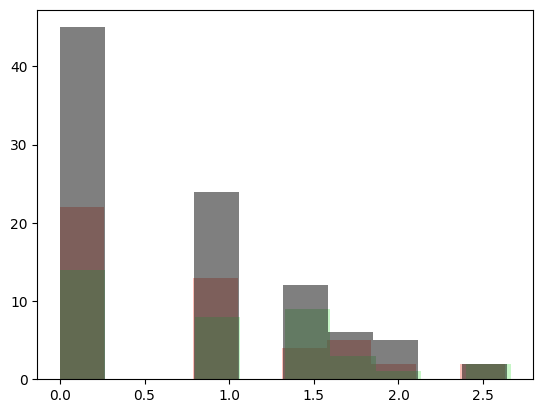

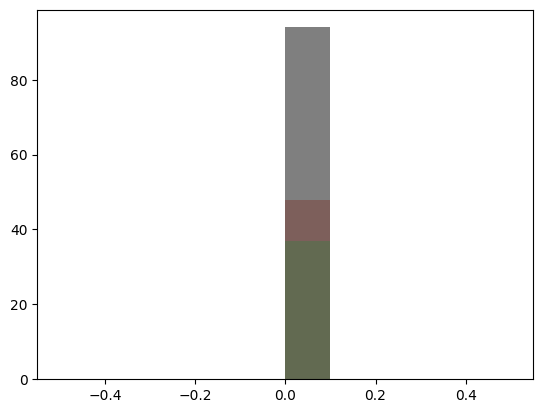

In [12]:
all_files = []
all_scores = []
for dir, _, files in os.walk("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    for file in files:
        scores = {}
        if file.endswith(".scores.json"):
            with open(os.path.join(os.path.abspath(dir), file)) as fh:
                all_files.append(os.path.basename(file))
                data = json.load(fh)
                for sig in data['signature_map']:
                    if sig['neutral_formula'] not in scores:
                        scores[sig['neutral_formula']] = 0
                    scores[sig['neutral_formula']] = max(scores[sig['neutral_formula']], sig['score'])
                all_scores.append(scores.get('C4H11N5', 0))
plt.title(f"C4H11N5 (Metformin) Score Distribution - All {len(all_scores)}")
plt.hist(all_scores)
plt.show()

pos_files = []
pos_scores = []
for dir, _, files in os.walk("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    for file in files:
        scores = {}
        if file.endswith(".scores.json"):
            with open(os.path.join(os.path.abspath(dir), file)) as fh:
                pos_files.append(os.path.basename(file))
                data = json.load(fh)
                if data['mode'] == 'pos':
                    for sig in data['signature_map']:
                        if sig['neutral_formula'] not in scores:
                            scores[sig['neutral_formula']] = 0
                        scores[sig['neutral_formula']] = max(scores[sig['neutral_formula']], sig['score'])
                    pos_scores.append(scores.get('C4H11N5', 0))
plt.title(f"C4H11N5 (Metformin) Score Distribution - Pos {len(pos_scores)}")
plt.hist(pos_scores)
plt.show()

neg_files = []
neg_scores = []
for dir, _, files in os.walk("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    for file in files:
        scores = {}
        if file.endswith(".scores.json"):
            with open(os.path.join(os.path.abspath(dir), file)) as fh:
                neg_files.append(os.path.basename(file))
                data = json.load(fh)
                if data['mode'] == 'neg':
                    for sig in data['signature_map']:
                        if sig['neutral_formula'] not in scores:
                            scores[sig['neutral_formula']] = 0
                        scores[sig['neutral_formula']] = max(scores[sig['neutral_formula']], sig['score'])
                    neg_scores.append(scores.get('C4H11N5', 0))
plt.title(f"C4H11N5 (Metformin) Score Distribution - Neg {len(neg_scores)}")
plt.hist(neg_scores)
plt.show()

color_map = {
    'Metformin': "salmon",
    'Placebo': 'lightgreen',
    'Other': 'k'
}

import pandas as pd
import seaborn as sns
meta = pd.read_excel("./metformin_meta.xlsx")
lookup = dict(zip(meta['Sample name'], meta['Treatment']))
print(lookup)

metformin = []
placebo = []
other = []
for pos_file, pos_score in zip(pos_files, pos_scores):
    exposure = lookup.get(pos_file.replace(".scores.json", ".mzML"), "Other")
    if exposure == 'Metformin':
        metformin.append(pos_score)
    elif exposure == 'Placebo':
        placebo.append(pos_score)
    else:
        other.append(pos_score)

plt.hist(metformin, color='salmon', alpha=0.5)
plt.hist(placebo, color='lightgreen', alpha=0.5)
plt.hist(other, color='k', alpha=0.5)
plt.show()

metformin = []
placebo = []
other = []
for neg_file, neg_score in zip(neg_files, neg_scores):
    exposure = lookup.get(neg_file.replace(".scores.json", ".mzML"), "Other")
    if exposure == 'Metformin':
        metformin.append(neg_score)
    elif exposure == 'Placebo':
        placebo.append(neg_score)
    else:
        other.append(neg_score)

plt.hist(metformin, color='salmon', alpha=0.5)
plt.hist(placebo, color='lightgreen', alpha=0.5)
plt.hist(other, color='k', alpha=0.5)
plt.show()


In [ ]:
import pandas as pd

meta = pd.read_excel("/Users/mitchjo/Projects/Asari-X/Asari-X/notebooks/metformin_search_bartlett/metformin_meta.xlsx")




['YW_20201206_061.mzML', 'YW_20201206_139.mzML', 'YW_20201206_153.mzML', 'YW_20201206_171.mzML', 'YW_20201206_199.mzML', 'YW_20201206_231.mzML', 'YW_20201210_061.mzML', 'YW_20201210_139.mzML', 'YW_20201210_153.mzML', 'YW_20201210_171.mzML', 'YW_20201210_199.mzML', 'YW_20201210_231.mzML']


YW_20201206_209.scores.json
YW_20201206_181.scores.json
YW_20201206_227.scores.json
YW_20201206_049.scores.json
YW_20201206_175.scores.json
YW_20201206_033_20201208153824.scores.json
YW_20201206_147.scores.json
YW_20201206_055.scores.json
YW_20201206_041_20201208162107.scores.json
YW_20201206_205.scores.json
YW_20201206_219.scores.json
YW_20201206_237.scores.json
YW_20201206_083.scores.json
YW_20201206_247.scores.json
YW_20201206_191.scores.json
YW_20201206_179.scores.json
YW_20201206_127.scores.json
YW_20201206_157.scores.json
YW_20201206_115.scores.json
YW_20201206_089.scores.json
YW_20201206_095.scores.json
YW_20201206_221.scores.json
YW_20201206_187.scores.json
YW_20201206_251.scores.json
YW_20201206_053.scores.json
YW_20201206_131.scores.json
YW_20201206_141.scores.json
YW_20201206_035_20201208154904.scores.json
YW_20201206_173.scores.json
YW_20201206_107_20201210165216.scores.json
YW_20201206_061.scores.json
YW_20201206_103.scores.json
YW_20201206_241.scores.json
YW_20201206_231.

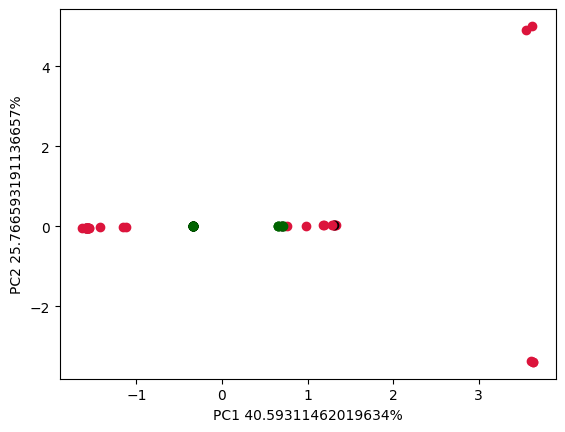

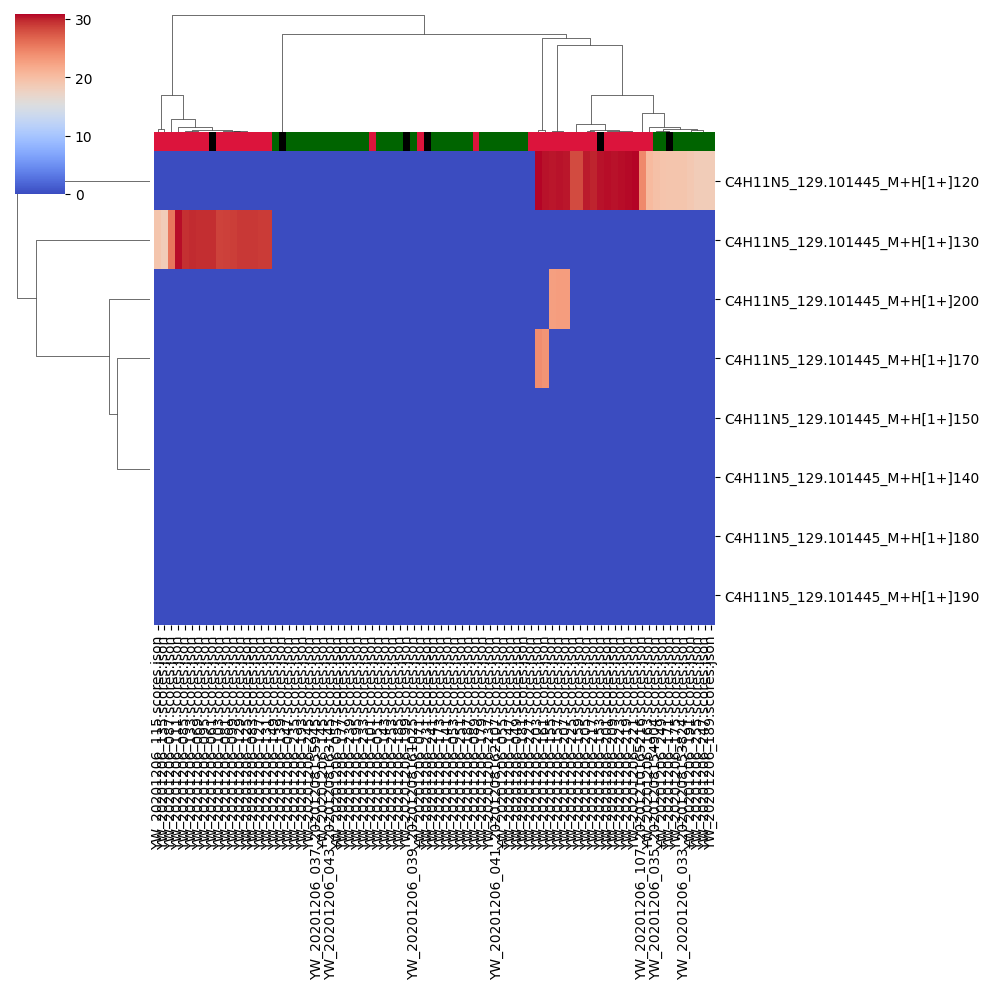

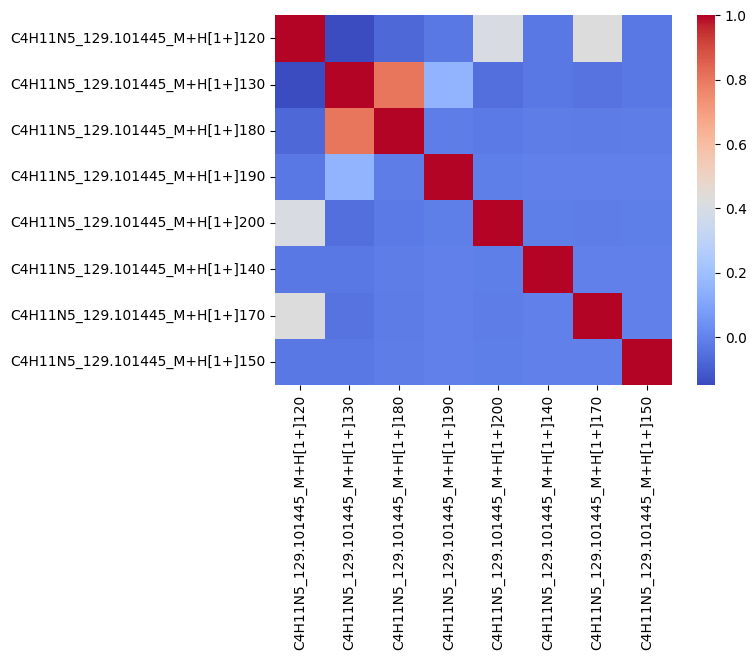

{'YW_20201206_209.scores.json': [30.48603732219254, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_257.scores.json': [28.54890096044897, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_181.scores.json': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_093.scores.json': [0.0, 30.581525763120197, 23.983213347703057, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_227.scores.json': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_267_20201208165305.scores.json': [21.09340208917223, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_215.scores.json': [27.153435067892744, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201203_005.scores.json': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_265.scores.json': [27.299796924013627, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_003_20201208150626.scores.json': [20.82818840574916, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_049.scores.json': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'YW_20201206_039.scores.json': [0.0, 0.0, 0.0, 0.0

In [35]:
import json
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sys.setrecursionlimit(int(1e6))
import pandas as pd
from mass2chem.formula import parse_chemformula_dict, dict_to_hill_formula
from random import sample as sample_r

apices = {}
integrals = {}
all_samples = []
scans = {}
dispersion = {}
empty = set()
treatments = {}
visits = {}


meta = pd.read_excel("/Users/mitchjo/Projects/Asari-X/Asari-X/notebooks/metformin_search_bartlett/metformin_meta.xlsx")

tmap = {}
for name, treatment in zip(meta["Sample name"], meta["Treatment"]):
    tmap[name] = treatment

transition_samples = []
sorted_names = sorted(meta["Sample name"])
for i, sn in enumerate(sorted_names):
    if i > 0:
        if not tmap[sorted_names[i-1]] == tmap[sorted_names[i]]:
            transition_samples.append(sorted_names[i])

for x in os.listdir("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    if x.endswith("scores.json") and "blank" not in x.lower():
        json_f = json.load(open(os.path.join("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData", x)))
        scores = json_f["scores"]
        mode = json_f["mode"]
        if int(x.split(".")[0].split("_")[2]) % 2:
            chrom = "hilic"
        else:
            chrom = "rp"
        if mode == "pos" and chrom == "hilic":
            for r in meta.to_dict(orient="records"):
                if r["Sample name"] == x.split(".")[0] + ".mzML":
                    treatments[x] = r['Treatment']
                    visits[x] = r['Visit']
                    break

            for base_sig, _d in scores.items():
                if x not in all_samples:
                    all_samples.append(x)
                if base_sig not in dispersion:
                    dispersion[base_sig] = []
                for d in _d:
                    sig = base_sig + str(round(d["apex"] / 10) * 10)
                    if sig not in integrals:
                        integrals[sig] = {}
                        scans[sig] = {}
                    if x not in integrals[sig]:
                        integrals[sig][x] = 0
                        scans[sig][x] = 0
                    integrals[sig][x] += d["integral"]
                    scans[sig][x] += d["scans"]
                    dispersion[base_sig].append(d["apex"])
all_samples = []
for x in os.listdir("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData"):
    if x.endswith("scores.json") and "blank" not in x.lower():
        json_f = json.load(open(os.path.join("/Users/mitchjo/Projects/Asari-X/Asari-X/TestData", x)))
        scores = json_f["scores"]
        mode = json_f["mode"]
        if mode == "pos" and chrom == "rp":
            all_samples.append(x)
            for sig in integrals:
                if x not in integrals[sig]:
                    integrals[sig][x] = 0


vectors = {s: [] for s in all_samples}
counts = {}
for sig in integrals:
    for s in all_samples:
        if s in integrals[sig]:
            vectors[s].append(np.log2(integrals[sig][s] + 1))
            if sig not in counts:
                counts[sig] = 0
            counts[sig] += 1
        else:
            vectors[s].append(0)

met = 0
pla = 0
for x, t in treatments.items():
    if t == "Metformin":
        met += 1
    else:
        pla += 1

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xs, Ys, Cs, Gs = [], [], [], []
markers = []
p = PCA(n_components=2)
S = StandardScaler()

new_samples = all_samples

color_map = {
    "Placebo": "darkgreen",
    "Metformin": "crimson",
    "Other": 'black',
    "V1": "royalblue",
    "V2": "indigo",
    "V3": "orange",
    "V4": "brown",
    "V5": "dimgrey",
    "V6": "pink"
}


if True:
    embed = p.fit_transform(S.fit_transform([vectors[a] for a in new_samples]))
    no_outliers = []
    for s, (x,y) in zip(new_samples, embed):
        if x < 3 and y < 5 and y > -2.5 and s in treatments:
        #if True and s in treatments:
            no_outliers.append(s)
            
    new_samples = no_outliers
    embed = p.fit_transform(S.fit_transform([vectors[a] for a in new_samples]))
    Cs1 = []
    for s,(x,y) in zip(new_samples, embed):
        Xs.append(x)
        Ys.append(y)
        print(s)
        if s.replace(".scores.json", ".mzML") in transition_samples:
            C = 'black'
        else:
            C = color_map[treatments[s]]
        Cs1.append(C)

        plt.scatter(Xs[-1], Ys[-1], c=C)
    plt.xlabel(f"PC1 {p.explained_variance_ratio_[0] * 100}%")
    plt.ylabel(f"PC2 {p.explained_variance_ratio_[1] * 100}%")
    plt.show()

sns.clustermap(np.array([vectors[a] for a in new_samples]).T, yticklabels=list(integrals.keys()), xticklabels=new_samples, cmap='coolwarm', col_colors=[Cs1])
plt.show()
M = []
for i in integrals:
    R = []
    si = [integrals[i].get(s, 0) for s in all_samples]
    for j in integrals:
        sj = [integrals[j].get(s, 0) for s in all_samples]
        R.append(np.corrcoef(si, sj)[0, 1])
    M.append(R)

sns.heatmap(M, xticklabels=list(integrals.keys()), yticklabels=list(integrals.keys()), cmap='coolwarm')
plt.show()

print(vectors)

In [41]:
Xs, Ys = [], []
for file, vector in vectors.items():
    Xs.append(vector)
    Ys.append(tmap.get(file.replace(".scores.json", ".mzML"), 'Unknown'))

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
RFC = RandomForestClassifier(n_estimators=100)
RFC.fit(Xs, Ys)
y_pred = RFC.predict(Xs)
accuracy_score(Ys, y_pred)


0.7926829268292683